# Data-Driven Market Structure Analysis: Spectral Methods, Clustering, and Unsupervised Evaluation

This notebook explores the structure of U.S. equity markets using a fully unsupervised,
data‑driven workflow. Using daily log returns from 104 large‑cap stocks (2006–2026), we analyze
how stocks move together, identify latent patterns in the return correlation matrix, and uncover
behavior-based market clusters using spectral methods and hierarchical clustering.

We first examine the empirical correlation structure through exploratory analysis and eigenvalue
decomposition, separating meaningful market factors from noise. The leading eigenvectors form a
low‑dimensional spectral embedding that captures the dominant co‑movement patterns across stocks.

Using this embedding, we apply hierarchical clustering (Ward linkage) to identify groups of stocks
with similar behavior. To evaluate how these data‑driven clusters relate to economic sectors, we use
Normalized Mutual Information (NMI), a non‑circular unsupervised metric comparing clusters to known
GICS sector labels. The resulting NMI score, along with a cluster–sector contingency analysis,
reveals both sector‑pure and cross‑sector behavioral groupings, highlighting the multi‑factor nature
of market structure.

In [ ]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


## Data download and cleaning

We download adjusted closing prices from Yahoo Finance using `yfinance`. The ticker list contains stocks from different sectors, including technology, healthcare, financials, energy, and consumer sectors.

After downloading the data, We:
- remove tickers that failed completely,
- fill remaining missing values,
- compute daily log returns,
- save the cleaned prices and returns.

In [ ]:
start_date = "2006-01-01"
end_date = "2026-02-20"

tickers = [
    # Tech
    "AAPL","MSFT","GOOGL","AMZN","NVDA","AVGO","CSCO","ORCL","IBM","INTC","TXN","QCOM","ADBE","AMAT","LRCX","AMD",

    # Communication / Media / Telecom
    "DIS","CMCSA","NFLX","TMUS","VZ","T",

    # Consumer Staples
    "PG","KO","PEP","WMT","COST","PM","MO","CL","KMB","MDLZ",

    # Consumer Discretionary
    "HD","LOW","MCD","SBUX","NKE","BKNG","TGT","TJX","F",

    # Financials
    "JPM","BAC","WFC","C","GS","MS","SCHW","BLK","AXP","V","MA","SPGI","CB",

    # Healthcare
    "JNJ","PFE","MRK","ABBV","LLY","AMGN","BMY","GILD","UNH","CVS","TMO","DHR","ABT","MDT","HUM",

    # Industrials
    "CAT","DE","HON","GE","BA","RTX","LMT","UPS","FDX",

    # Energy
    "XOM","CVX","COP","EOG","SLB",

    # Utilities
    "NEE","DUK","SO","AEP","EXC","SRE",

    # Materials / Metals / Chemicals
    "LIN","APD","SHW","NUE","FCX","ECL",

    # REITs
    "AMT","PLD","SPG","O",

    # Gold / Precious Metals
    "NEM","GOLD","AEM","FNV","WPM"
]

df = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

prices = df["Close"].copy()

# Remove tickers that failed completely
prices = prices.dropna(axis=1, how="all")

# Fill remaining missing values
prices = prices.ffill().bfill()

# Compute daily log returns
r = np.log(prices).diff().dropna()

# Save cleaned files
os.makedirs("data", exist_ok=True)
prices.to_csv("data/prices.csv")
r.to_csv("data/returns.csv")

valid_tickers = prices.columns.tolist()
removed_tickers = sorted(set(tickers) - set(valid_tickers))

print("Number of valid tickers:", len(valid_tickers))
print("Removed tickers:", removed_tickers)
print("Prices shape:", prices.shape)
print("Returns shape:", r.shape)

prices.head()

Number of valid tickers: 104
Removed tickers: []
Prices shape: (5064, 104)
Returns shape: (5063, 104)


Ticker,AAPL,ABBV,ABT,ADBE,AEM,AEP,AMAT,AMD,AMGN,AMT,...,TMUS,TXN,UNH,UPS,V,VZ,WFC,WMT,WPM,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,2.239734,20.731642,11.929832,38.520000,16.761433,16.871889,13.331354,32.400002,54.354595,19.961163,...,43.655537,20.638285,47.622765,39.110409,12.441912,9.702676,18.379145,10.255757,4.965527,29.426701
2006-01-04,2.246327,20.731642,11.947927,38.419998,16.632149,16.844788,13.447721,32.560001,54.097580,20.575352,...,43.655537,20.824556,47.738503,39.162182,12.441912,9.986924,18.165974,10.275720,5.040010,29.477028
2006-01-05,2.228649,20.731642,12.101771,38.070000,16.289925,16.749950,13.600456,33.680000,53.312969,20.509546,...,43.655537,21.197092,47.591915,39.177708,12.441912,10.101902,18.145802,10.135959,4.849664,29.331085
2006-01-06,2.286177,20.731642,12.334031,39.000000,16.662565,17.011883,14.087741,33.779999,52.825958,20.823950,...,43.655537,21.389561,48.525402,38.944752,12.441912,10.142336,18.252388,10.178113,5.006907,29.909838
2006-01-09,2.278687,20.731642,12.792521,38.380001,16.791857,16.758984,14.196839,33.250000,53.421200,21.277281,...,43.655537,21.221922,47.368195,39.421013,12.441912,10.184402,18.249506,10.140404,4.907595,29.894737


## Why use returns instead of prices?

Raw stock prices are not directly comparable across companies, since different stocks trade at very different price levels. Returns measure relative changes in price, which makes comparison more meaningful.

In this notebook We use **daily log returns**:

\[
r_t = \log(P_t) - \log(P_{t-1})
\]

Log returns are standard in finance because they are easier to work with mathematically and are well suited for correlation-based analysis.

## Histogram of returns

This histogram shows the distribution of daily log returns across all stocks and dates. It helps us understand whether returns are concentrated near zero and whether extreme positive or negative moves occur.

Most daily returns are expected to be close to zero, while large shocks appear in the tails.

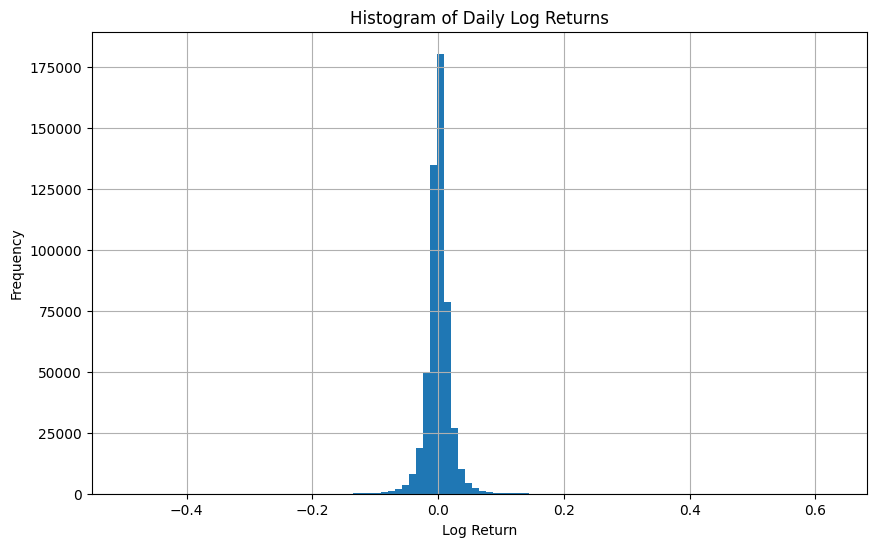

In [ ]:
plt.figure(figsize=(10, 6))
r.stack().hist(bins=100)
plt.title("Histogram of Daily Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()

## Sample stock prices over time

This line chart shows adjusted closing prices for a small sample of stocks from different sectors. It gives a quick view of long-term growth, variation in volatility, and major changes over time.

These plots show that stocks do not all move in the same way and motivate later correlation and clustering analysis.

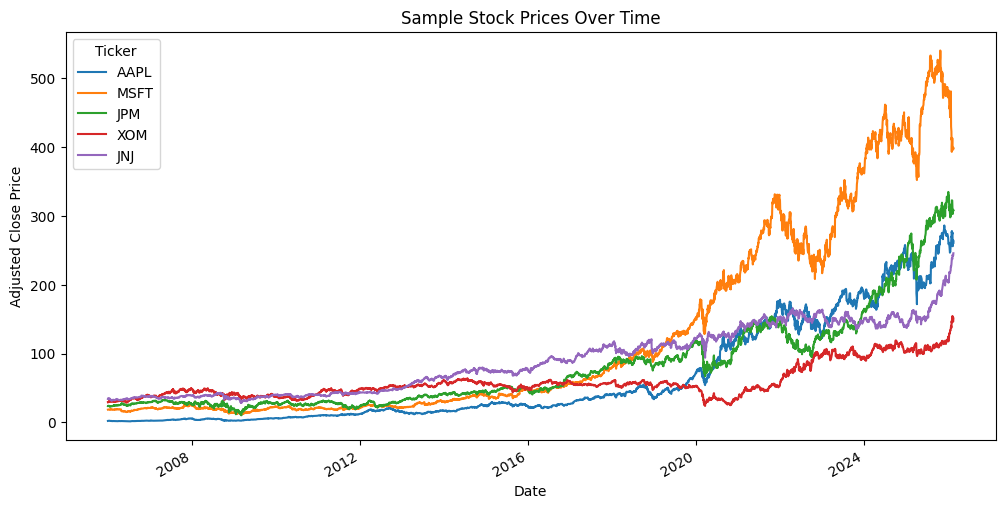

In [ ]:
sample_tickers = [t for t in ["AAPL", "MSFT", "JPM", "XOM", "JNJ"] if t in prices.columns]

prices[sample_tickers].plot(figsize=(12, 6))
plt.title("Sample Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.show()

## Sector summary

The stock list includes companies from many sectors. A sector summary helps show whether the dataset is well distributed across industries or concentrated in a few areas.

This matters because sector composition often affects correlation structure and clustering outcomes.

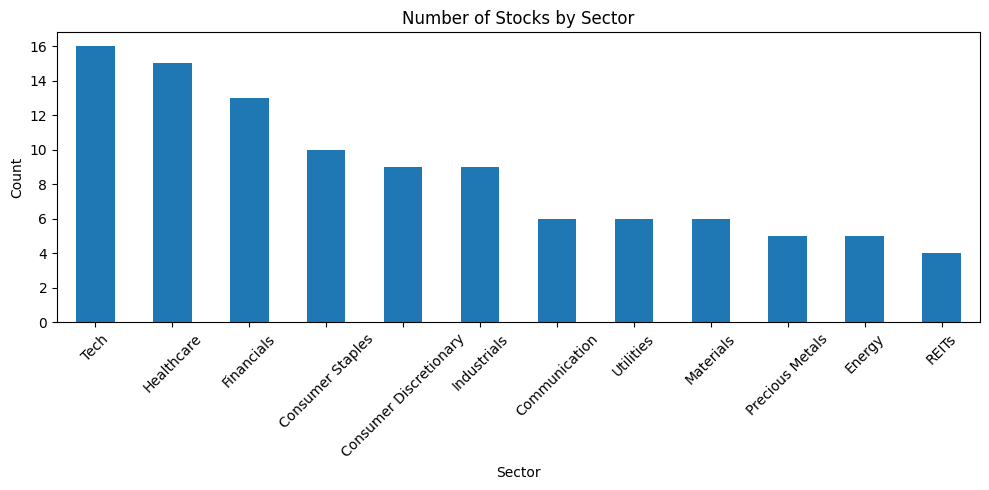

,count
Tech,16
Healthcare,15
Financials,13
Consumer Staples,10
Consumer Discretionary,9
Industrials,9
Communication,6
Utilities,6
Materials,6
Precious Metals,5


In [ ]:
sector_map = {
    "AAPL":"Tech","MSFT":"Tech","GOOGL":"Tech","AMZN":"Tech","NVDA":"Tech","AVGO":"Tech","CSCO":"Tech","ORCL":"Tech","IBM":"Tech","INTC":"Tech","TXN":"Tech","QCOM":"Tech","ADBE":"Tech","AMAT":"Tech","LRCX":"Tech","AMD":"Tech",
    "DIS":"Communication","CMCSA":"Communication","NFLX":"Communication","TMUS":"Communication","VZ":"Communication","T":"Communication",
    "PG":"Consumer Staples","KO":"Consumer Staples","PEP":"Consumer Staples","WMT":"Consumer Staples","COST":"Consumer Staples","PM":"Consumer Staples","MO":"Consumer Staples","CL":"Consumer Staples","KMB":"Consumer Staples","MDLZ":"Consumer Staples",
    "HD":"Consumer Discretionary","LOW":"Consumer Discretionary","MCD":"Consumer Discretionary","SBUX":"Consumer Discretionary","NKE":"Consumer Discretionary","BKNG":"Consumer Discretionary","TGT":"Consumer Discretionary","TJX":"Consumer Discretionary","F":"Consumer Discretionary",
    "JPM":"Financials","BAC":"Financials","WFC":"Financials","C":"Financials","GS":"Financials","MS":"Financials","SCHW":"Financials","BLK":"Financials","AXP":"Financials","V":"Financials","MA":"Financials","SPGI":"Financials","CB":"Financials",
    "JNJ":"Healthcare","PFE":"Healthcare","MRK":"Healthcare","ABBV":"Healthcare","LLY":"Healthcare","AMGN":"Healthcare","BMY":"Healthcare","GILD":"Healthcare","UNH":"Healthcare","CVS":"Healthcare","TMO":"Healthcare","DHR":"Healthcare","ABT":"Healthcare","MDT":"Healthcare","HUM":"Healthcare",
    "CAT":"Industrials","DE":"Industrials","HON":"Industrials","GE":"Industrials","BA":"Industrials","RTX":"Industrials","LMT":"Industrials","UPS":"Industrials","FDX":"Industrials",
    "XOM":"Energy","CVX":"Energy","COP":"Energy","EOG":"Energy","SLB":"Energy",
    "NEE":"Utilities","DUK":"Utilities","SO":"Utilities","AEP":"Utilities","EXC":"Utilities","SRE":"Utilities",
    "LIN":"Materials","APD":"Materials","SHW":"Materials","NUE":"Materials","FCX":"Materials","ECL":"Materials",
    "AMT":"REITs","PLD":"REITs","SPG":"REITs","O":"REITs",
    "NEM":"Precious Metals","GOLD":"Precious Metals","AEM":"Precious Metals","FNV":"Precious Metals","WPM":"Precious Metals"
}

sector_series = pd.Series({t: sector_map[t] for t in prices.columns if t in sector_map})
sector_counts = sector_series.value_counts()

plt.figure(figsize=(10, 5))
sector_counts.plot(kind="bar")
plt.title("Number of Stocks by Sector")
plt.xlabel("Sector")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sector_counts

## Correlation matrix of returns

Correlation measures how two stocks move together. A correlation close to 1 means the two stocks tend to move in the same direction. A value near 0 means weak linear relation, while a negative value means they often move in opposite directions.

In finance, the correlation matrix is important because it helps reveal:
- market-wide co-movement,
- sector structure,
- diversification patterns,
- common risk factors.

The heatmap below shows pairwise correlations between stock returns over a one-year window. Blocks of similar color often indicate groups of stocks with similar behavior.

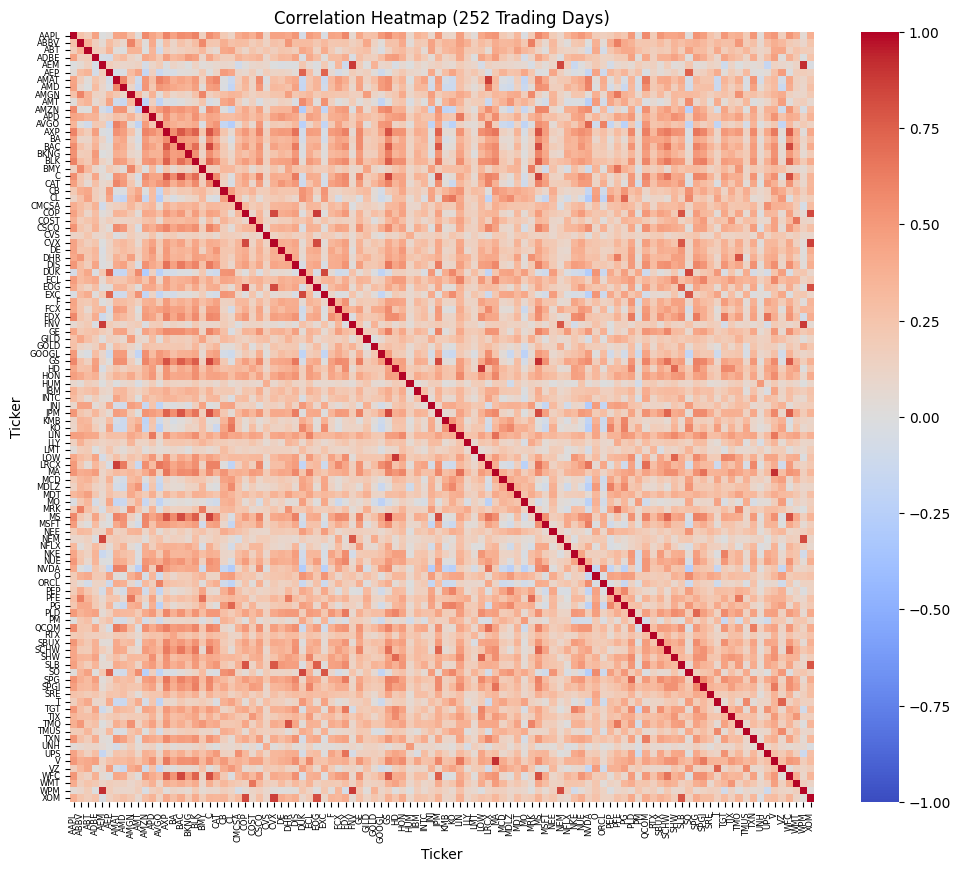

In [ ]:
W = 252
analysis_end_date = "2025-12-31"

window_r = r.loc[:analysis_end_date].tail(W)
C = window_r.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(C, cmap="coolwarm", vmin=-1, vmax=1, center=0, xticklabels=True, yticklabels=True)
plt.title(f"Correlation Heatmap ({W} Trading Days)")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.show()

## Distribution of correlation values

A histogram of correlation values gives a compact summary of how strongly stocks are related overall. This is useful because the full heatmap is large, while the histogram shows the overall spread of pairwise correlation values in one figure.

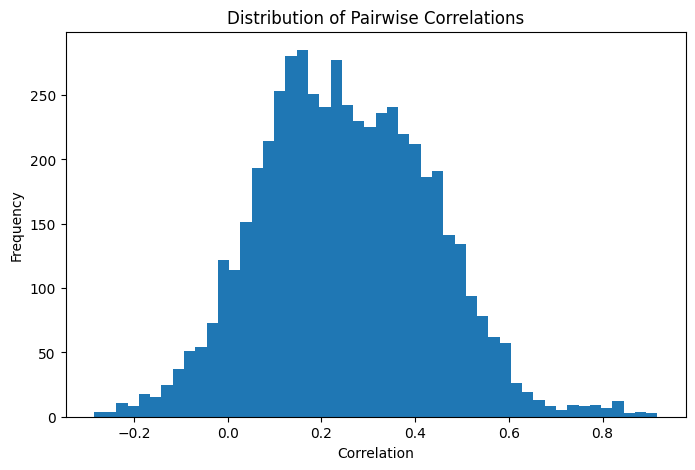

In [ ]:
corr_vals = C.values[np.triu_indices_from(C.values, k=1)]

plt.figure(figsize=(8, 5))
plt.hist(corr_vals, bins=50)
plt.title("Distribution of Pairwise Correlations")
plt.xlabel("Correlation")
plt.ylabel("Frequency")
plt.show()

## Volatility distribution

Volatility is measured here by the standard deviation of returns. Looking at the distribution of volatilities helps compare how much different stocks fluctuate over the selected window.

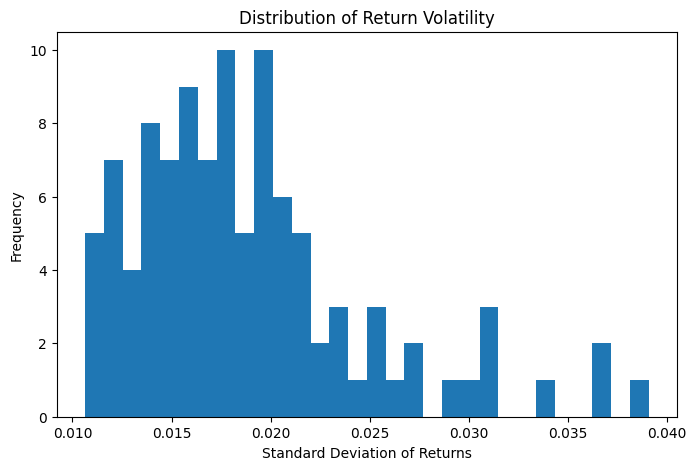

In [ ]:
vol = window_r.std()

plt.figure(figsize=(8, 5))
plt.hist(vol, bins=30)
plt.title("Distribution of Return Volatility")
plt.xlabel("Standard Deviation of Returns")
plt.ylabel("Frequency")
plt.show()

## Eigenvalue analysis

The eigenvalues of the correlation matrix show how much variation is explained by different directions in the data.

In financial data:
- the largest eigenvalue often reflects a broad market factor,
- other large eigenvalues may reflect sector-level or group-level structure.

To separate signal from random noise, We compare the observed eigenvalues to the Marčenko–Pastur (MP) upper bound. Eigenvalues above this bound are treated as potentially significant.

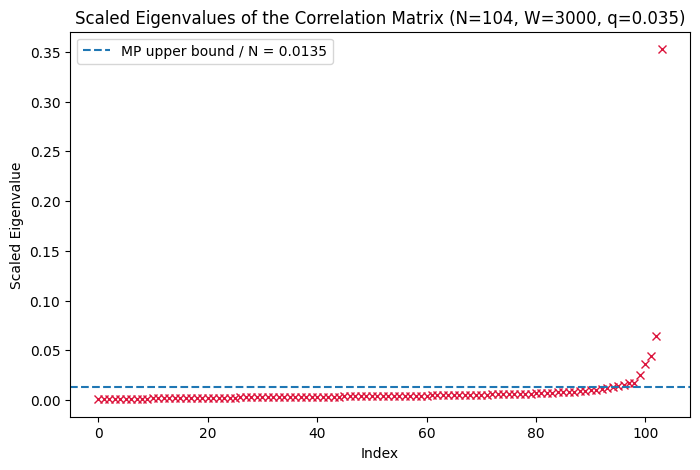

Number of significant eigenvalues: 9


In [ ]:
W = 3000
analysis_end_date = "2026-02-20"

window_r = r.loc[:analysis_end_date].tail(W)
C = window_r.corr()

N = C.shape[0]
eigvals, vecs = np.linalg.eigh(C.values)

eigvals_scaled = eigvals / N
q = N / W

lam_minus = (1 - np.sqrt(q))**2
lam_plus = (1 + np.sqrt(q))**2
lam_plus_scaled = lam_plus / N

plt.figure(figsize=(8, 5))
plt.plot(eigvals_scaled, linestyle="None", marker="x", color="crimson")
plt.axhline(lam_plus_scaled, linestyle="--", label=f"MP upper bound / N = {lam_plus_scaled:.4f}")
plt.title(f"Scaled Eigenvalues of the Correlation Matrix (N={N}, W={W}, q={q:.3f})")
plt.xlabel("Index")
plt.ylabel("Scaled Eigenvalue")
plt.legend()
plt.show()

k_sig = np.sum(eigvals_scaled > lam_plus_scaled)
print("Number of significant eigenvalues:", k_sig)

## Eigenvector analysis

Eigenvectors show the directions associated with the main factors in the correlation matrix. The entries of an eigenvector are called loadings.

These loadings tell us how strongly each stock contributes to a given factor. If a few stocks have especially large loadings, then those stocks dominate that factor. This often reveals hidden structure such as:
- sector effects,
- defensive vs cyclical behavior,
- groups of stocks reacting similarly to market conditions.

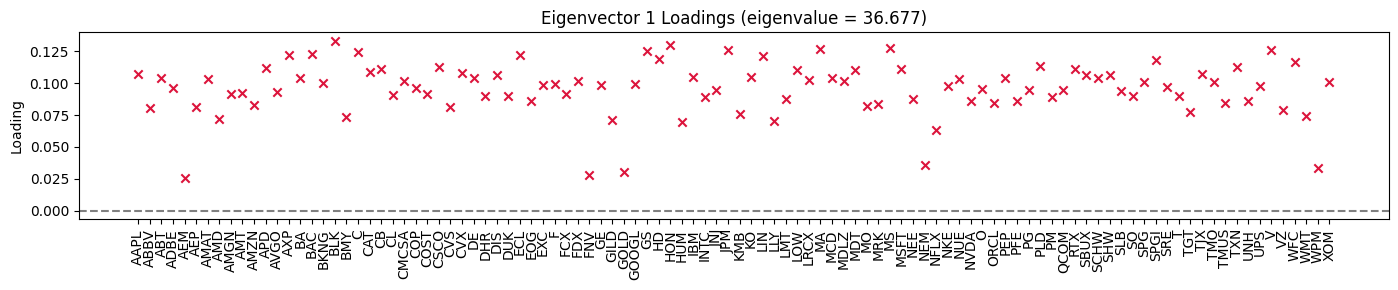

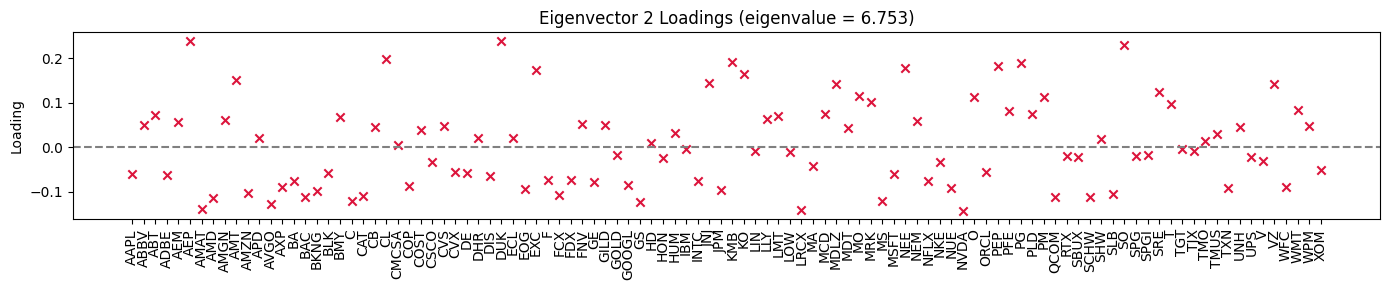

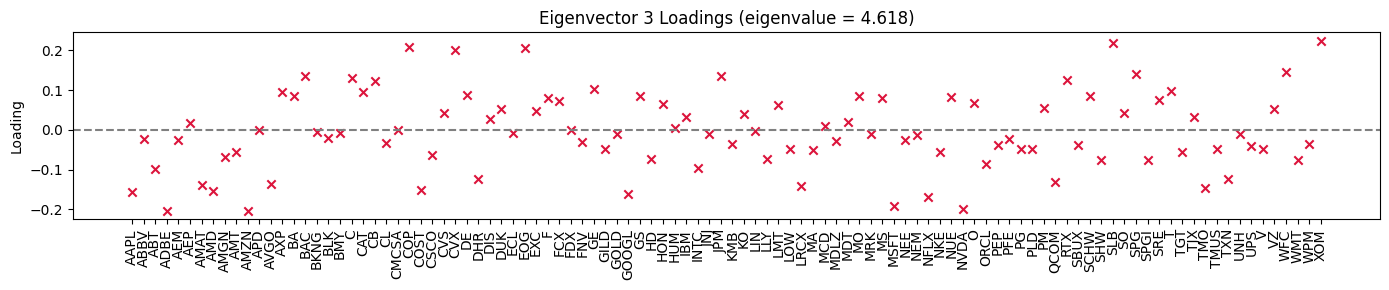

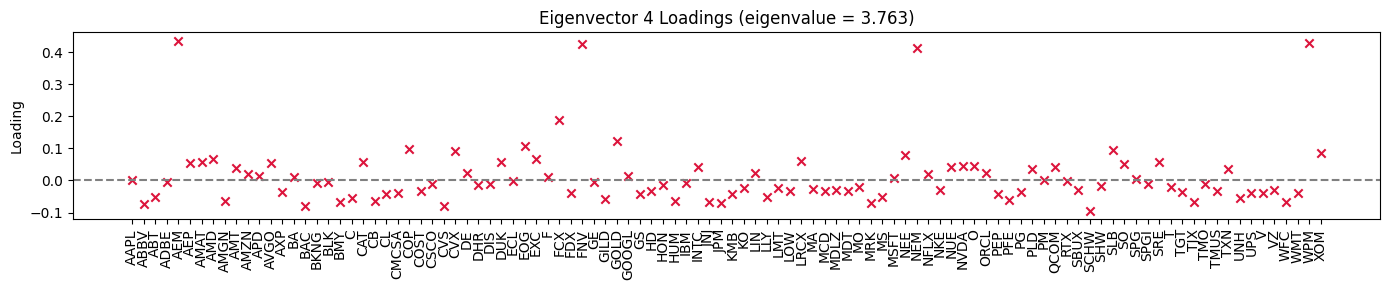

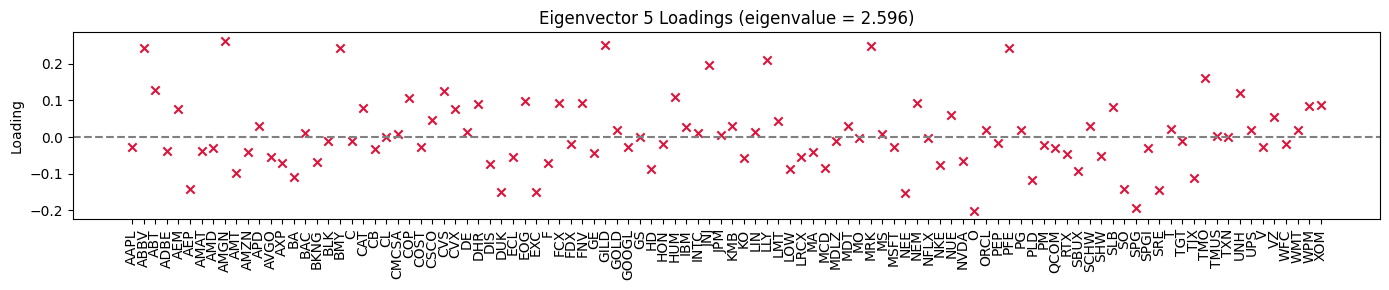

In [ ]:
s = 5
tickers_corr = C.columns.to_list()
x = np.arange(len(tickers_corr))

for j in range(s):
    v = vecs[:, -(j + 1)]

    if v[np.argmax(np.abs(v))] < 0:
        v = -v

    plt.figure(figsize=(14, 3))
    plt.scatter(x, v, marker="x", color="crimson")
    plt.axhline(0, linestyle="--", color="gray")
    plt.title(f"Eigenvector {j+1} Loadings (eigenvalue = {eigvals[-(j+1)]:.3f})")
    plt.xticks(x, tickers_corr, rotation=90)
    plt.ylabel("Loading")
    plt.tight_layout()
    plt.show()

## Inspecting one eigenvector

To make the factor interpretation more concrete, We inspect one of the leading eigenvectors and list the stocks with the largest positive and negative loadings.

This helps identify which names are most responsible for a given factor.

In [ ]:
ticker = C.columns.to_numpy()

component_idx = 2   # 1 = top eigenvector, 2 = second, etc.
v = vecs[:, -component_idx]

print("Fraction positive:", np.mean(v > 0))
print("Fraction negative:", np.mean(v < 0))

idx = np.argsort(np.abs(v))[::-1]
print("Top contributors:", ticker[idx[:10]])

pos_idx = np.where(v > 0)[0]
pos_sorted = pos_idx[np.argsort(v[pos_idx])[::-1]]
print("Top positive (by loading):", ticker[pos_sorted[:10]])

neg_idx = np.where(v < 0)[0]
neg_sorted = neg_idx[np.argsort(v[neg_idx])]
print("Top negative (by loading):", ticker[neg_sorted[:10]])

Fraction positive: 0.5288461538461539
Fraction negative: 0.47115384615384615
Top contributors: ['DUK' 'AEP' 'SO' 'CL' 'KMB' 'PG' 'PEP' 'NEE' 'EXC' 'KO']
Top positive (by loading): ['NVDA' 'LRCX' 'AMAT' 'AVGO' 'GS' 'MS' 'C' 'AMD' 'BAC' 'SCHW']
Top negative (by loading): ['DUK' 'AEP' 'SO' 'CL' 'KMB' 'PG' 'PEP' 'NEE' 'EXC' 'KO']


## Spectral embedding

We use the leading eigenvectors to build a low-dimensional embedding of the stocks. This creates a geometric representation of similarity: stocks that are close in the embedding tend to have similar correlation structure.

This embedding is the input for clustering.

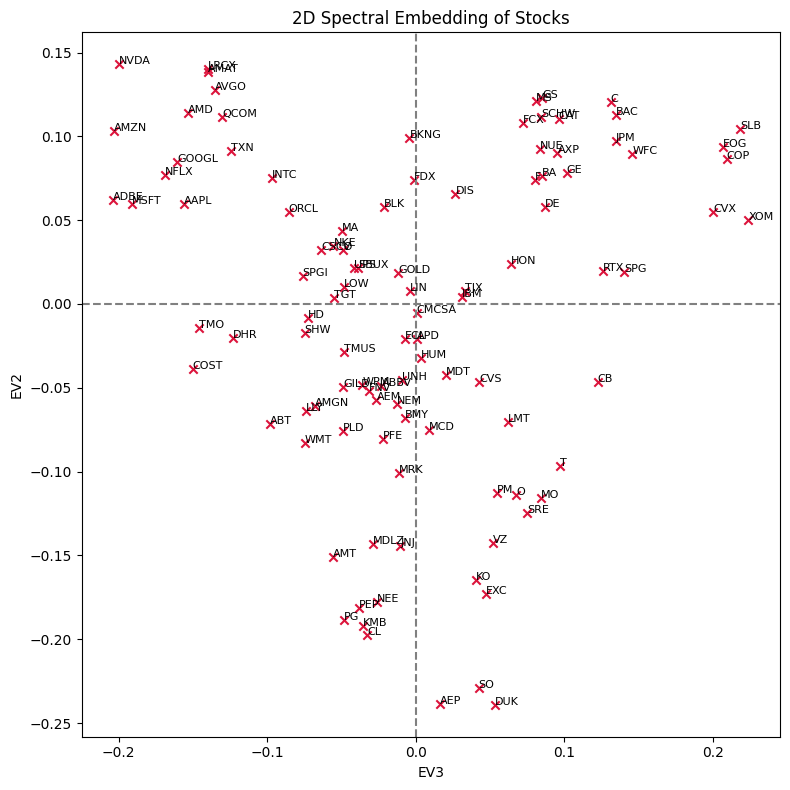

,EV1,EV2,EV3
Ticker,,,
AAPL,0.107103,0.059614,-0.155943
ABBV,0.080313,-0.049239,-0.023185
ABT,0.103941,-0.071514,-0.098219
ADBE,0.096295,0.062186,-0.203624
AEM,0.025905,-0.057575,-0.026524


In [ ]:
E = pd.DataFrame(
    np.column_stack([vecs[:, -1], vecs[:, -2], vecs[:, -3]]),
    index=C.columns,
    columns=["EV1", "EV2", "EV3"]
)

plt.figure(figsize=(8, 8))
plt.scatter(E["EV3"], E["EV2"], marker="x", color="crimson")

for t in E.index:
    plt.text(E.loc[t, "EV3"], E.loc[t, "EV2"], t, fontsize=8)

plt.axhline(0, linestyle="--", color="gray")
plt.axvline(0, linestyle="--", color="gray")
plt.xlabel("EV3")
plt.ylabel("EV2")
plt.title("2D Spectral Embedding of Stocks")
plt.tight_layout()
plt.show()

E.head()

## Clustering: Hierarchical Clustering on Spectral Embedding

We apply **hierarchical clustering with Ward linkage** to the 3-dimensional spectral embedding of returns.  
This unsupervised method groups stocks with similar co-movement patterns based solely on behavior, without using sector labels.

We use **k = 8 clusters**, balancing interpretability with granularity.  
The results reveal sector-heavy clusters (e.g., Technology, Healthcare) as well as mixed clusters driven by shared underlying factors.

In [ ]:
Z = linkage(E.values, method="ward")

k = 8
labels = fcluster(Z, k, criterion="maxclust") - 1

cluster_df = pd.DataFrame({
    "Ticker": E.index,
    "Cluster": labels
}).set_index("Ticker").sort_values("Cluster")

for j in range(k):
    print(f"\nCluster {j+1}:")
    print(cluster_df.index[cluster_df["Cluster"] == j].to_numpy())


Cluster 1:
['BAC' 'AXP' 'BA' 'C' 'CAT' 'DE' 'F' 'FCX' 'GE' 'GS' 'JPM' 'MS' 'WFC'
 'SCHW' 'NUE']

Cluster 2:
['EOG' 'RTX' 'XOM' 'SPG' 'SLB' 'CVX' 'COP' 'CB']

Cluster 3:
['SRE' 'EXC' 'MO' 'T' 'VZ' 'O' 'PM' 'KO']

Cluster 4:
['AMT' 'SO' 'PEP' 'NEE' 'CL' 'MDLZ' 'JNJ' 'KMB' 'DUK' 'AEP' 'PG']

Cluster 5:
['QCOM' 'AVGO' 'MSFT' 'NFLX' 'TXN' 'NVDA' 'GOOGL' 'AAPL' 'LRCX' 'AMD'
 'AMZN' 'ADBE' 'AMAT']

Cluster 6:
['LOW' 'CSCO' 'BLK' 'MA' 'INTC' 'BKNG' 'DIS' 'HD' 'FDX' 'TGT' 'NKE' 'SHW'
 'V' 'UPS' 'SPGI' 'ORCL' 'SBUX']

Cluster 7:
['WMT' 'COST' 'DHR' 'LLY' 'ABT' 'AMGN' 'PLD' 'TMO']

Cluster 8:
['ABBV' 'MCD' 'LMT' 'LIN' 'IBM' 'GILD' 'HON' 'HUM' 'GOLD' 'ECL' 'FNV'
 'AEM' 'APD' 'BMY' 'CMCSA' 'CVS' 'MDT' 'TMUS' 'NEM' 'PFE' 'MRK' 'TJX'
 'UNH' 'WPM']


## Unsupervised Evaluation: Normalized Mutual Information (NMI)

Because clustering is unsupervised, we avoid supervised classification (which would create circular validation).  
Instead, we evaluate the quality of our clusters using **Normalized Mutual Information (NMI)**.

NMI measures how similar two different label assignments are:
- 0.0 = no relationship  
- 1.0 = perfect alignment  

Here, we compare:
- **Unsupervised spectral clusters**, and  
- **Known GICS sectors**

This gives a principled, non-circular assessment of how well data-driven clusters reflect real economic structure.

In [ ]:

from sklearn.metrics import normalized_mutual_info_score

# sector_series was computed earlier in the EDA section
nmi = normalized_mutual_info_score(labels, sector_series.loc[E.index])
print(f"Normalized Mutual Information (Clusters vs Sectors): {nmi:.3f}")


Normalized Mutual Information (Clusters vs Sectors): 0.527


In [ ]:
pd.crosstab(labels, sector_series.loc[E.index])

col_0,Communication,Consumer Discretionary,Consumer Staples,Energy,Financials,Healthcare,Industrials,Materials,Precious Metals,REITs,Tech,Utilities
row_0,,,,,,,,,,,,
0,0,1,0,0,8,0,4,2,0,0,0,0
1,0,0,0,5,1,0,1,0,0,1,0,0
2,2,0,3,0,0,0,0,0,0,1,0,2
3,0,0,5,0,0,1,0,0,0,1,0,4
4,1,0,0,0,0,0,0,0,0,0,12,0
5,1,6,0,0,4,0,2,1,0,0,3,0
6,0,0,2,0,0,5,0,0,0,1,0,0
7,2,2,0,0,0,9,2,3,5,0,1,0


## Cluster summary table

To make the clustering results easier to interpret, We also summarize the number of stocks in each cluster.

In [ ]:
cluster_summary = cluster_df.groupby("Cluster").size().rename("Count").to_frame()
cluster_summary

,Count
Cluster,
0,15
1,8
2,8
3,11
4,13
5,17
6,8
7,24


## Cluster-colored embedding plot

This plot shows the spectral embedding with points colored by cluster assignment. It is useful for presentation because it makes the clustering structure easier to see visually.

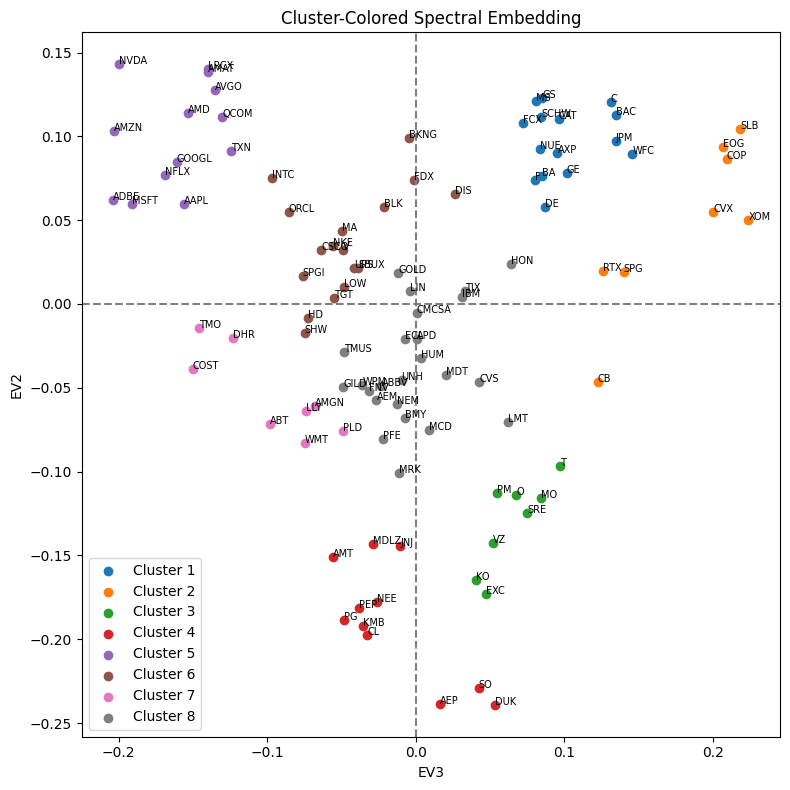

In [ ]:
plt.figure(figsize=(8, 8))

for j in range(k):
    idx = labels == j
    plt.scatter(E.loc[idx, "EV3"], E.loc[idx, "EV2"], label=f"Cluster {j+1}")

for t in E.index:
    plt.text(E.loc[t, "EV3"], E.loc[t, "EV2"], t, fontsize=7)

plt.axhline(0, linestyle="--", color="gray")
plt.axvline(0, linestyle="--", color="gray")
plt.xlabel("EV3")
plt.ylabel("EV2")
plt.title("Cluster-Colored Spectral Embedding")
plt.legend()
plt.tight_layout()
plt.show()

## Save embedding and clustering results

The final outputs for the spectral and clustering part are saved to:

- `results/embedding.csv`
- `results/clusters.csv`

In [ ]:
os.makedirs("results", exist_ok=True)

E.to_csv("results/embedding.csv")
cluster_df.to_csv("results/clusters.csv")

print("Saved:")
print(" - results/embedding.csv")
print(" - results/clusters.csv")

Saved:
 - results/embedding.csv
 - results/clusters.csv


## Interpretation of Spectral Clusters and NMI Evaluation

The spectral embedding reveals a clear geometric structure in return co-movements.  
Applying hierarchical clustering to this embedding produces **8 data-driven market clusters**.

### Key Findings

- **Technology cluster**: One cluster is composed almost entirely of Technology stocks, showing strong sector coherence.
- **Healthcare cluster**: Another cluster contains predominantly Healthcare stocks, reflecting shared defensive characteristics.
- **Cross-sector clusters**: Several clusters mix Consumer Staples, Utilities, Financials, and Industrials—indicating shared risk-factor exposures rather than strict sector definitions.
- **Moderate NMI score (0.527)**:  
  This confirms **partial alignment** between clusters and sectors:
  - Some clusters match sectors very well  
  - Others represent broader economic themes (cyclical vs defensive behavior, sensitivity to macro trends)

### Economic Interpretation

Stock returns are influenced by multiple overlapping **latent factors**:
- Market-wide risk  
- Sector factors  
- Interest-rate sensitivity  
- Defensive vs cyclical dynamics  

Because of this, stocks do **not** always cluster cleanly along sector boundaries.  
The spectral clustering reveals **behavioral (functional)** groupings rather than **nominal (sector-based)** categories.

### Conclusion

The unsupervised modeling pipeline successfully captures meaningful co-movement structure.  
While clustering does not perfectly reproduce sector labels, the NMI and cluster compositions demonstrate that spectral clusters reflect *real economic relationships* embedded in stock return data.